<a href="https://colab.research.google.com/github/radhakrishnan-omotec/mritunjay-repo/blob/main/FamilyEmotion_IndianDataset2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from keras import layers, Sequential
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

# -------------------- DATA LOADING --------------------

# Path to the main directory containing the class folders
main_directory = r"C:\Users\OMOLP049\Documents\Mritunjay Gupta\New2\FINAL"

# List to store data for DataFrame
data = []

# Traverse the folders and collect file paths and labels
for label in os.listdir(main_directory):
    label_path = os.path.join(main_directory, label)
    if os.path.isdir(label_path):  # Check if it's a directory
        for file in os.listdir(label_path):
            if file.endswith('.wav'):  # Check if it's a .wav file
                file_path = os.path.join(label_path, file)
                data.append({"speech": file_path, "label": label})

# Create a DataFrame
df = pd.DataFrame(data)

# Display class distribution
print(df['label'].value_counts())

# -------------------- FEATURE EXTRACTION --------------------

def extract_mfcc(filename, duration=3, offset=0.5):
    y, sr = librosa.load(filename, duration=duration, offset=offset)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

# Apply MFCC extraction to all audio files
df['mfcc'] = df['speech'].apply(lambda x: extract_mfcc(x))

# Convert list of MFCCs to numpy array
X = np.array(df['mfcc'].tolist())

# Expand dimensions for CNN input
X = np.expand_dims(X, -1)  # Shape: (num_samples, 40, 1)

# -------------------- LABEL ENCODING --------------------

enc = OneHotEncoder()
y = enc.fit_transform(df[['label']]).toarray()  # Convert labels to one-hot encoding
class_labels = enc.categories_[0]  # Get class names

# -------------------- TRAIN-TEST SPLIT --------------------

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

label
A1(OLD MAN)        630
A2(OLD WOMEN)      630
A3(YOUNG MAN)      630
A4(YOUNG WOMEN)    630
Name: count, dtype: int64


In [ ]:


# -------------------- CNN MODEL --------------------

model = Sequential([
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(40, 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),  # Dropout to prevent overfitting

    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(y.shape[1], activation='softmax')  # Number of classes = y.shape[1]
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 6, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,828 (491.52 KB)

 Trainable params: 125,828 (491.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


# -------------------- COMPILE MODEL --------------------

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',  # Adam optimizer for better convergence
    metrics=['accuracy']
)

# -------------------- TRAINING --------------------

# Callbacks to reduce learning rate and save best model
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=10, min_lr=0.000001)
mcp_save = ModelCheckpoint('model/newcnn2.keras', save_best_only=True, monitor='val_loss', mode='min')

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=128,
    callbacks=[mcp_save, lr_reduce]
)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3962 - loss: 2.4428 - val_accuracy: 0.9782 - val_loss: 0.3474 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8738 - loss: 0.3577 - val_accuracy: 0.9940 - val_loss: 0.0409 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9713 - loss: 0.0970 - val_accuracy: 0.9960 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9863 - loss: 0.0496 - val_accuracy: 0.9940 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9887 - loss: 0.1022 - val_accuracy: 0.9940 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9926 - loss: 0.0193 - val_accuracy: 0.9940 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9943 - loss: 0.0193 - 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9956 - loss: 0.0072     
Test Accuracy: 99.40%
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


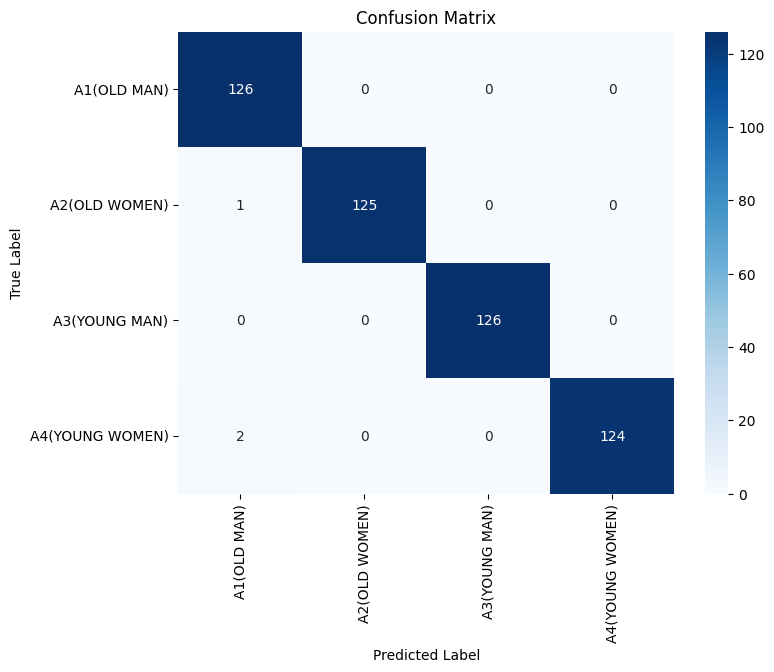


Classification Report:
                 precision    recall  f1-score   support

    A1(OLD MAN)       0.98      1.00      0.99       126
  A2(OLD WOMEN)       1.00      0.99      1.00       126
  A3(YOUNG MAN)       1.00      1.00      1.00       126
A4(YOUNG WOMEN)       1.00      0.98      0.99       126

       accuracy                           0.99       504
      macro avg       0.99      0.99      0.99       504
   weighted avg       0.99      0.99      0.99       504



In [ ]:

# -------------------- TESTING --------------------

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# -------------------- CONFUSION MATRIX --------------------

# Predict class probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))


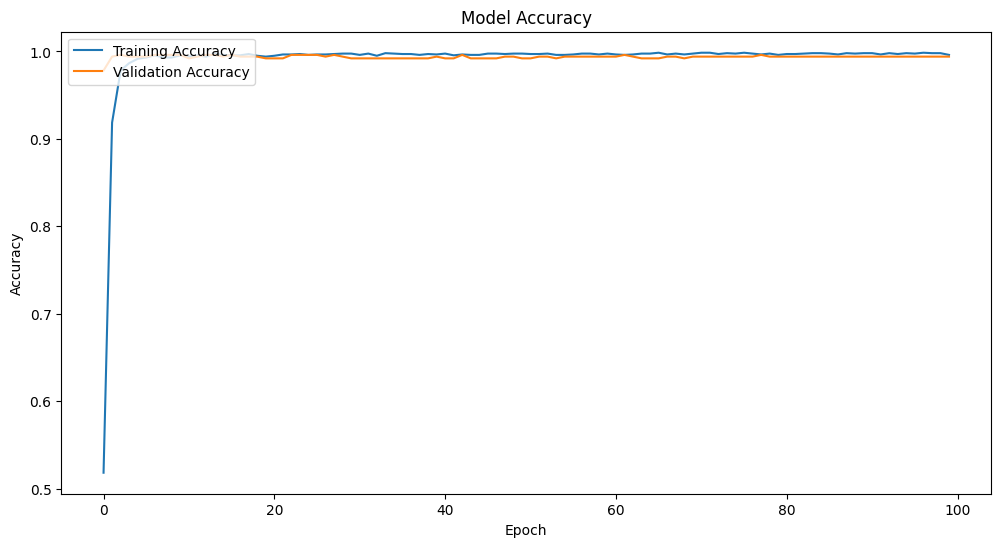

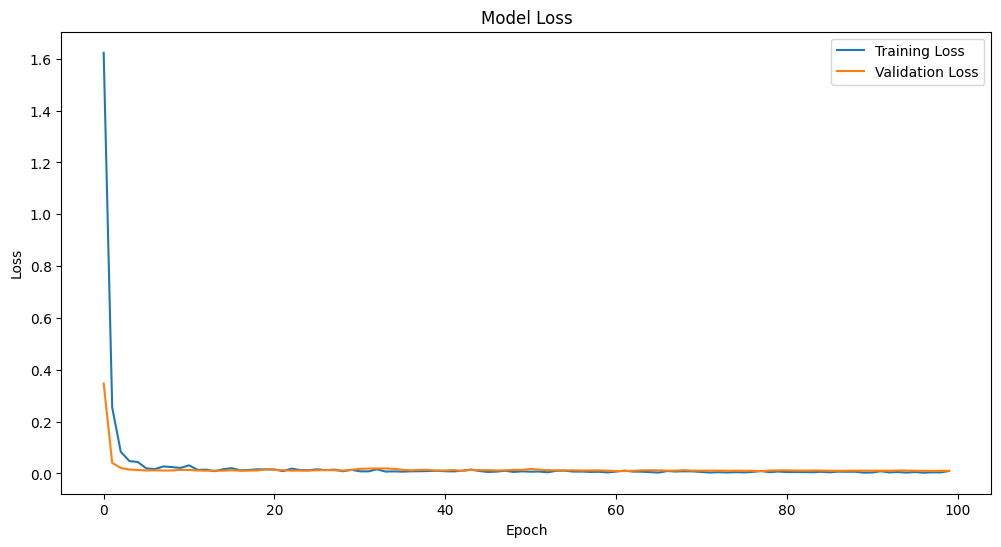

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
def plot_accuracy(history):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='upper left')
    plt.show()

# Plot training & validation loss values
def plot_loss(history):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.show()

# Call the functions to plot
plot_accuracy(history)
plot_loss(history)
